# Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import itertools
from math import e
from datetime import datetime, timedelta
import glob
import metpy.calc as mpcalc
from metpy.units import units
import warnings; warnings.simplefilter('ignore')
from matplotlib.dates import date2num, DateFormatter
import matplotlib.dates as mdates
import xarray as xr
from matplotlib.dates import date2num, DateFormatter
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib
matplotlib.rc('xtick', labelsize=13) 
matplotlib.rc('ytick', labelsize=13)
# import datetime

# Import Styles and colors

In [2]:
from palettable.cartocolors.qualitative import Prism_8
from palettable.cartocolors.qualitative import Safe_10
from palettable.matplotlib import Viridis_10
from palettable.colorbrewer.diverging import PRGn_4
from palettable.matplotlib import Plasma_10
from palettable.cartocolors.sequential import Sunset_3

cluster_c = PRGn_4.mpl_colors
cluster_colors = cluster_c[2], cluster_c[0], cluster_c[3], cluster_c[1]
viridis = Viridis_10.mpl_colors
plasma = Plasma_10.mpl_colors
sunset3 = Sunset_3.mpl_colors
c_l= [viridis[7], viridis[2],viridis[4],viridis[8], viridis[6]]
c_v = [c_l[3], c_l[0], c_l[4], c_l[2], c_l[1], viridis[1], viridis[0]]
color_cb = Safe_10.mpl_colors
prism = Prism_8.mpl_colors
blue = prism[1]
green = prism[3]
purple = prism[0]
red = prism[7]
orange = prism[6]
yellow = prism[5]
gray = "#303039"
color_list = [blue, green, purple, red, orange, yellow, gray]
style = "/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle"
plt.style.use(style)

Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 15 ("xtick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 16 ("ytick.color: 'k'")
Duplicate key in file '/Users/cneumaie/OneDrive - Colostate/Styles/christine-paperlight.mpstyle', line 27 ('axes.edgecolor:222222')


# Define paths

In [3]:
dataPath = (
    "/Users/cneumaie/OneDrive - Colostate/Research/Drone_Profiles/00_Data/"
)

figPath = "/Users/cneumaie/OneDrive - Colostate/Research/Drone_Profiles/02_Figures/"

# Functions for reading in data

## Functions for reading in iMet files and processing the data (drone data)

In [4]:
def rh_from_dewpt(TD, T):
    return 100*(np.exp((17.625*TD)/(243.04+TD))/np.exp((17.625*T)/(243.04+T))) 

In [5]:
def correct_humidity(imet_dataset):
    '''bias correct the RH measurment on the imet sensor'''
    im = imet_dataset
    dps = mpcalc.dewpoint_from_relative_humidity((im['Temp_RH'].values)*units("degC"),
                                 (im['RH'].values)/100.0)
    im['Dewpoint'] = np.array(dps)
    new_rh_cor = rh_from_dewpt(im['Dewpoint'], im['Temp'])
    im['Recalc_RH'] = new_rh_cor
    mx_ratio = mpcalc.mixing_ratio_from_relative_humidity((im["P"].values)*units("hPa"), (im["Temp"].values)*units("degC"), 
                                               im["RH"].values/100).to('g/kg')
    im["Mixing_ratio(g/kg)"] = mx_ratio

    return im

In [6]:
def clean_imet_data(
    path,
    imetCols=[
        "XQ-iMet-XQ Pressure",
        "XQ-iMet-XQ Air Temperature",
        "XQ-iMet-XQ Humidity",
        "XQ-iMet-XQ Humidity Temp",
        "XQ-iMet-XQ Date",
        "XQ-iMet-XQ Time",
        "XQ-iMet-XQ Longitude",
        "XQ-iMet-XQ Latitude",
        "XQ-iMet-XQ Altitude",
        "XQ-iMet-XQ Sat Count",
    ],
    imetnewCols=[
        "P",
        "Temp",
        "RH",
        "Temp_RH",
        "Date",
        "Time",
        "Lon",
        "Lat",
        "Alt",
        "SatCount",
    ],
):
    df = pd.read_csv(path, parse_dates=True)
    df = df[imetCols]
    df.columns = imetnewCols

    df = df[df.Date.str[:4] == "2023"]
    df = df[df.Date.str[8:10] != "00"]

    df = df[df.SatCount > 0]

    df["Datetime"] = pd.to_datetime(df.Date + " " + df.Time)
    df_2 = correct_humidity(df)
    Temp_K = (df_2["Temp"].values+273.15)*units("K")
    df_2["Theta"] = mpcalc.potential_temperature((df_2["P"].values)*units("hPa"), Temp_K)
    df_2["T_v(K)"] = mpcalc.virtual_temperature(Temp_K,df_2["Mixing_ratio(g/kg)"].values*units("g/kg"))
    df_2["T_v(C)"] = df_2["T_v(K)"].values-273.15

    return df_2

In [7]:
def convert_datetime_log(input_datetime):
    '''converts datetime into the format required for getting
    the corresponding airdata log for each flight'''
    
    # Parse the input string into a datetime object
    dt = datetime.strptime(input_datetime, "%Y-%m-%d %H:%M:%S")
    
    # Format the day with the ordinal suffix
    day = dt.day
    if 10 <= day % 100 <= 20:  # Special case for teens
        suffix = "th"
    else:
        suffix = {1: "st", 2: "nd", 3: "rd"}.get(day % 10, "th")
    day_with_suffix = f"{day}{suffix}"
    
    # Format the datetime into the desired string
    output_datetime = dt.strftime(f"%b-{day_with_suffix}-%Y-%I-%M%p")
    

    return output_datetime, dt,day_with_suffix

In [8]:
def get_airdata(input_datetime):
    '''gets airdata converted log for the selected flight'''
    converted_datetime, dt,day_with_suffix = convert_datetime_log(input_datetime)
    airdataPath = f"{dataPath}/Converted Logs/Pileus Jr"
    try:
        airdata_log = pd.read_csv(f"{airdataPath}/{converted_datetime}-Flight-Airdata.csv")
        return airdata_log
    except:
            for i in range(1,7):
                dt_forward = dt + timedelta(minutes=i)
                forward_datetime = dt_forward.strftime(f"%b-{day_with_suffix}-%Y-%I-%M%p")
                try:
                    airdata_log = pd.read_csv(f"{airdataPath}/{forward_datetime}-Flight-Airdata.csv")
                    return airdata_log
                except:
                    continue
            for i in range(1,7):
                dt_backward = dt - timedelta(minutes=i)
                backward_datetime = dt_backward.strftime(f"%b-{day_with_suffix}-%Y-%I-%M%p")
                try:
                    airdata_log = pd.read_csv(f"{airdataPath}/{backward_datetime}-Flight-Airdata.csv")
                    return airdata_log
                except:
                    continue
            print("converted log not found")

## Functions for surface station data

In [9]:
def get_times(FilePath):
    '''Converts surface station time data to datetime format and returns a pandas
    dataframe'''
    
    sfc_file = xr.open_dataset(glob.glob(FilePath+'BACS2_QC*.nc')[0])
    sfc_file
    df = sfc_file.to_dataframe()
    
    date_init = datetime(2022,1,1)   ##file is in format of seconds since Jan 1 2022
    ###Now we will convert the time to datetime function using a for loop
    datetime_list = []
    for i in range(len(sfc_file.time.values)):
        datetime_list.append(date_init+timedelta(minutes=int(sfc_file['time'][i].values))+timedelta(hours=6))###convert to UTC
    df['datetime'] = datetime_list
    ds = df.set_index('datetime') ###change the index to the datetime variable
    
    return ds

## Functions for radiosonde data

In [10]:
def open_iMet(imet_filepath):
    '''Opens iMet Sounding to a pandas dataframe'''
    df = pd.read_table(open(imet_filepath, errors='ignore'),   ###reading in file as a pandas dataframe
                  skiprows=[1,2], sep=r'\s+', index_col = False)
    df['Temp'] = df['Temp']+273.15 ###Converts to K
    
    return df

# Get logs

In [11]:
stack_log = pd.read_csv(f"{dataPath}stack_final_flightlog.csv", parse_dates = True)
prof_log = pd.read_csv(f"{dataPath}CP_prof_log_BACS2_v15duv_CPpairs_orig.csv", parse_dates = True)

# Get drone data

## profiling drone

In [12]:
prof_list_23 = []
for IOP in range(23,24):
    # Select flight
    log_IOP = prof_log[prof_log["IOP"] == IOP]
    for flight in np.unique(log_IOP.Flight):
        flt = prof_log[(prof_log["IOP"]==IOP) & (prof_log["Flight"] == flight)].reset_index()
        # read unaspirated imet
        uPath = f"{dataPath}/imet/{flt.Unaspirated[0]}-{pd.to_datetime(flt.Date[0]).strftime('%Y%m%d')}.csv"
        u = clean_imet_data(uPath)
        # use manual takeoff/landing times as initial guess
        u = u[(u.Datetime >= flt.starttime.iloc[0]) & (u.Datetime <= flt.endtime.iloc[-1])]
        u = u.reset_index()
        
        # get the converted air data drone log
        airdata_log = get_airdata(flt.starttime_ad[0])
        
        #convert datetime column to datetime format
        airdata_log["datetime(utc)"] = pd.to_datetime(airdata_log["datetime(utc)"])
        
        ### select only the times in the flight for the drone log
        airdata_log = airdata_log[(airdata_log["datetime(utc)"] >= flt.starttime.iloc[0]) & (airdata_log["datetime(utc)"] <= flt.endtime.iloc[-1])]


        
        # Select only numeric columns for aggregation
        numeric_cols = airdata_log.select_dtypes(include="number")
        # create a new drone log dataframe with only datetime and numeric columns for the flight
        numbers_ad_log = pd.concat([airdata_log["datetime(utc)"],numeric_cols], axis=1)
        # take the mean of the drone log data by second to match the timeseries of the iMet data
        ad_log_mean = numbers_ad_log.groupby("datetime(utc)").mean().reset_index()
        # Convert height to m
        ad_log_mean["height_AGL(m)"] = ad_log_mean['height_above_ground_at_drone_location(feet)']*0.3048
        # add drone height to iMet dataframe
        u["Height_AGL"] = ad_log_mean["height_AGL(m)"]
        asc_log = flt[flt["Type"] == "ascending"]
        dsc_log = flt[flt["Type"] == "descending"]
        
        for leg in range(len(dsc_log.index)):
 
            a = u[(u.Datetime >= asc_log.starttime.iloc[leg]) & (u.Datetime <= asc_log.endtime.iloc[leg])]
            d = u[(u.Datetime >= dsc_log.starttime.iloc[leg]) & (u.Datetime <= dsc_log.endtime.iloc[leg])]
            a["ascent_flag"] = True
            d["ascent_flag"] = False
            a["IOP"] = IOP
            d["IOP"] = IOP
            a["Flight"] = flight
            d["Flight"] = flight
            a["leg_id"] = asc_log["Unnamed: 0"].iloc[leg]
            d["leg_id"] = dsc_log["Unnamed: 0"].iloc[leg]
            prof_list_23.append(a)
            prof_list_23.append(d)
            

In [13]:
prof_list_26 = []
for IOP in range(26,27):
    # Select flight
    log_IOP = prof_log[prof_log["IOP"] == IOP]
    for flight in np.unique(log_IOP.Flight):
        flt = prof_log[(prof_log["IOP"]==IOP) & (prof_log["Flight"] == flight)].reset_index()
        # read unaspirated imet
        uPath = f"{dataPath}/imet/{flt.Unaspirated[0]}-{pd.to_datetime(flt.Date[0]).strftime('%Y%m%d')}.csv"
        u = clean_imet_data(uPath)
        # use manual takeoff/landing times as initial guess
        u = u[(u.Datetime >= flt.starttime.iloc[0]) & (u.Datetime <= flt.endtime.iloc[-1])]
        u = u.reset_index()
        
        # get the converted air data drone log
        airdata_log = get_airdata(flt.starttime_ad[0])
        
        #convert datetime column to datetime format
        airdata_log["datetime(utc)"] = pd.to_datetime(airdata_log["datetime(utc)"])
        
        ### select only the times in the flight for the drone log
        airdata_log = airdata_log[(airdata_log["datetime(utc)"] >= flt.starttime.iloc[0]) & (airdata_log["datetime(utc)"] <= flt.endtime.iloc[-1])]


        
        # Select only numeric columns for aggregation
        numeric_cols = airdata_log.select_dtypes(include="number")
        # create a new drone log dataframe with only datetime and numeric columns for the flight
        numbers_ad_log = pd.concat([airdata_log["datetime(utc)"],numeric_cols], axis=1)
        # take the mean of the drone log data by second to match the timeseries of the iMet data
        ad_log_mean = numbers_ad_log.groupby("datetime(utc)").mean().reset_index()
        # Convert height to m
        ad_log_mean["height_AGL(m)"] = ad_log_mean['height_above_ground_at_drone_location(feet)']*0.3048
        # add drone height to iMet dataframe
        u["Height_AGL"] = ad_log_mean["height_AGL(m)"]
        u["Alt_AGL"] = u["Alt"]-1655
        asc_log = flt[flt["Type"] == "ascending"]
        dsc_log = flt[flt["Type"] == "descending"]
        
        for leg in range(len(dsc_log.index)):
 
            a = u[(u.Datetime >= asc_log.starttime.iloc[leg]) & (u.Datetime <= asc_log.endtime.iloc[leg])]
            d = u[(u.Datetime >= dsc_log.starttime.iloc[leg]) & (u.Datetime <= dsc_log.endtime.iloc[leg])]
            a["ascent_flag"] = True
            d["ascent_flag"] = False
            a["IOP"] = IOP
            d["IOP"] = IOP
            a["Flight"] = flight
            d["Flight"] = flight
            a["leg_id"] = asc_log["Unnamed: 0"].iloc[leg]
            d["leg_id"] = dsc_log["Unnamed: 0"].iloc[leg]
            prof_list_26.append(a)
            prof_list_26.append(d)
            

In [14]:
df_prof_23 = pd.concat(prof_list_23,ignore_index=True)
df_prof_26 = pd.concat(prof_list_26,ignore_index=True)

In [15]:
df_prof_23 = df_prof_23.sort_values(by="leg_id").sort_index()
df_prof_26 = df_prof_26.sort_values(by="leg_id").sort_index()
df_prof_23

,index,P,Temp,RH,Temp_RH,Date,Time,Lon,Lat,Alt,...,Recalc_RH,Mixing_ratio(g/kg),Theta,T_v(K),T_v(C),Height_AGL,ascent_flag,IOP,Flight,leg_id
0,3109,830.56,17.30,49.5,18.87,2023/06/10,20:31:03,-104.776481,40.809823,1679.825,...,54.663999,7.402269,306.272663,291.747222,18.597222,18.667143,True,23,2,177
1,3110,830.32,17.37,49.4,18.86,2023/06/10,20:31:04,-104.776482,40.809822,1681.810,...,54.278989,7.422473,306.371773,291.821050,18.671050,21.150001,True,23,2,177
2,3111,830.10,17.56,48.4,18.89,2023/06/10,20:31:05,-104.776482,40.809824,1685.117,...,52.645621,7.361277,306.595352,292.001246,18.851246,23.560001,True,23,2,177
3,3112,829.76,17.72,47.5,18.91,2023/06/10,20:31:06,-104.776477,40.809825,1687.906,...,51.212851,7.299973,306.800004,292.151275,19.001275,26.180001,True,23,2,177
4,3113,829.53,17.89,46.4,18.96,2023/06/10,20:31:07,-104.776473,40.809826,1690.437,...,49.649925,7.208674,307.003630,292.306105,19.156105,29.143334,True,23,2,177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4113,12442,829.30,15.06,59.2,14.88,2023/06/11,01:54:12,-104.776123,40.809644,1704.873,...,58.543443,7.688932,304.042492,289.546687,16.396687,NaN,False,23,7,227
4114,12443,829.63,15.09,59.2,14.89,2023/06/11,01:54:13,-104.776127,40.809648,1702.136,...,58.468270,7.700872,304.039578,289.578886,16.428886,NaN,False,23,7,227
4115,12444,829.70,15.07,59.1,14.90,2023/06/11,01:54:14,-104.776125,40.809652,1698.987,...,58.482331,7.677038,304.011153,289.554681,16.404681,NaN,False,23,7,227
4116,12445,830.12,15.08,59.1,14.92,2023/06/11,01:54:15,-104.776127,40.809657,1695.980,...,58.520049,7.678106,303.977744,289.564911,16.414911,NaN,False,23,7,227


## Now for hovering drones

In [16]:
stack_list_23 = []
drones = ["Cb", "Ac", "St"]
alts = [120,235,350]
for IOP in range(23,24):
    # Select flight
    log_IOP = stack_log[stack_log["iop"] == IOP]
    # cb_log = log_IOP[
    for flight in np.unique(log_IOP["flight_id"]):
        for alt in alts:
            # print(IOP, drone, flight)
            # print(flt)
            flt = stack_log[(stack_log["iop"]==IOP) & (stack_log["flight_id"] == flight) & (stack_log["nominal_altitude"] == alt)].reset_index()
            if not flt.empty:
                # read unaspirated imet
                uPath = f"{dataPath}/imet/{flt.sensor_unaspirated[0]}-{pd.to_datetime(flt.iop_date_local[0]).strftime('%Y%m%d')}.csv"
                u = clean_imet_data(uPath)
                # use manual takeoff/landing times as initial guess
                u = u[(u.Datetime >= flt.unaspirated_start_time_utc.iloc[0]) & (u.Datetime <= flt.unaspirated_end_time_utc.iloc[-1])]
                u = u.reset_index()

                u["IOP"] = IOP
                u["Flight"] = flight
                u["nominal_altitude"] = alt
                stack_list_23.append(u)

stack_list_26 = []
drones = ["Cb", "Ac", "St"]
alts = [120,235,350]
for IOP in range(26,27):
    # Select flight
    log_IOP = stack_log[stack_log["iop"] == IOP]
    # cb_log = log_IOP[
    for flight in np.unique(log_IOP["flight_id"]):
        for alt in alts:
            # print(IOP, drone, flight)
            # print(flt)
            flt = stack_log[(stack_log["iop"]==IOP) & (stack_log["flight_id"] == flight) & (stack_log["nominal_altitude"] == alt)].reset_index()
            if not flt.empty:
                # read unaspirated imet
                uPath = f"{dataPath}/imet/{flt.sensor_unaspirated[0]}-{pd.to_datetime(flt.iop_date_local[0]).strftime('%Y%m%d')}.csv"
                u = clean_imet_data(uPath)
                # use manual takeoff/landing times as initial guess
                u = u[(u.Datetime >= flt.unaspirated_start_time_utc.iloc[0]) & (u.Datetime <= flt.unaspirated_end_time_utc.iloc[-1])]
                u = u.reset_index()
                

                u["IOP"] = IOP
                u["Flight"] = flight
                u["nominal_altitude"] = alt
                stack_list_26.append(u)


In [17]:
df_stack_23 = pd.concat(stack_list_23, ignore_index=True)
df_stack_26 = pd.concat(stack_list_26, ignore_index=True)

In [18]:
# df_stack.Flight.unique()

# Get Surface station data

In [19]:
sfc_df = get_times(dataPath)
press = (sfc_df.pressure.values)*units.hPa
temp = (sfc_df.temperature.values)*units.degC
rh = (sfc_df.rh.values)/100
temp_K = (sfc_df.temperature.values + 273.15)*units.K
mixing_ratio = mpcalc.mixing_ratio_from_relative_humidity(press, temp_K, rh)
t_d = mpcalc.dewpoint_from_relative_humidity(temp,rh)
theta_e = mpcalc.equivalent_potential_temperature(press,temp,t_d)
sfc_df["MR"] = mixing_ratio*1000
sfc_df["theta_e"] = theta_e

In [20]:
sfc_iop23 =  sfc_df.where(sfc_df.iop==23)
iop23 = sfc_iop23
iop26 = sfc_df.where(sfc_df.iop==26)

In [21]:
iop23["LT_Time"] = iop23.index - pd.Timedelta(hours=6)
iop26["LT_Time"] = iop23.index - pd.Timedelta(hours=6)

In [22]:
iop23

,iop,temperature,rh,pressure,wspeed,wdir,u,v,MR,theta_e,LT_Time
datetime,,,,,,,,,,,
2023-05-19 19:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-19 13:28:00
2023-05-19 19:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-19 13:29:00
2023-05-19 19:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-19 13:30:00
2023-05-19 19:31:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-19 13:31:00
2023-05-19 19:32:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-05-19 13:32:00
...,...,...,...,...,...,...,...,...,...,...,...
2023-06-27 19:02:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-27 13:02:00
2023-06-27 19:03:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-27 13:03:00
2023-06-27 19:04:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-06-27 13:04:00


# Get radiosonde data

In [23]:
radiosondePath = f"{dataPath}radiosonde/" 

In [24]:
### IOP 23 CP1
r = 7
radiosonde_23 = open_iMet(glob.glob(f"{radiosondePath}20230610_BACS0{r}/*TSPOTINT.txt")[0])
### IOP 26 CP1
r = 3
radiosonde_26 = open_iMet(glob.glob(f"{radiosondePath}20230617_BACS0{r}/*TSPOTINT.txt")[0])

In [25]:
radiosonde_23["UTC_Time2"] = pd.to_datetime(radiosonde_23["UTC_Time"])+pd.Timedelta(hours=12)
radiosonde_26["UTC_Time2"] = pd.to_datetime(radiosonde_26["UTC_Time"])+pd.Timedelta(hours=12)
radiosonde_23["LT_Time"] = radiosonde_23["UTC_Time2"] -pd.Timedelta(hours = 6)
radiosonde_26["LT_Time"] = radiosonde_26["UTC_Time2"] -pd.Timedelta(hours = 6)

In [26]:
# radiosonde

# Seperate the data we want

## Drone data

In [27]:
df_prof_flt_23 = df_prof_23[df_prof_23["Flight"]== 4] ### for IOP 23 CP
df_prof_flt_26 = df_prof_26[df_prof_26["Flight"]== 2] ##For flight 1 ofIOP26 CP1
# df_prof_flt = df_prof[df_prof["Flight"]== 3] ##For flight 2 ofIOP26 CP1

In [28]:
df_stack_flt_23 = df_stack_23[df_stack_23["Flight"]==78] ### for IOP 23 CP
df_stack_flt_26 = df_stack_26[df_stack_26["Flight"]==93] ### For flight 1 of IOP26CP1
# df_stack_flt = df_stack[df_stack["Flight"]==94] ### For flight 1 of IOP26CP1

In [29]:
df_stack_flt_23["LT_Time"] = df_stack_flt_23["Datetime"]- pd.Timedelta(hours = 6)
df_stack_flt_26["LT_Time"] = df_stack_flt_26["Datetime"]- pd.Timedelta(hours = 6)
df_stack_flt_23["LT"] = df_stack_flt_23.Time - pd.Timedelta(hours = 6)
df_stack_flt_26["LT"] = df_stack_flt_26.Time - pd.Timedelta(hours = 6)

In [30]:
df_prof_flt_23["LT_Time"] = df_prof_flt_23["Datetime"]- pd.Timedelta(hours = 6)
df_prof_flt_26["LT_Time"] = df_prof_flt_26["Datetime"]- pd.Timedelta(hours = 6)
df_prof_flt_23["LT"] = df_prof_flt_23.Time - pd.Timedelta(hours = 6)
df_prof_flt_26["LT"] = df_prof_flt_26.Time - pd.Timedelta(hours = 6)

In [31]:
df_stack_flt_23

,index,P,Temp,RH,Temp_RH,Date,Time,Lon,Lat,Alt,...,Recalc_RH,Mixing_ratio(g/kg),Theta,T_v(K),T_v(C),IOP,Flight,nominal_altitude,LT_Time,LT
4697,5762,819.98,17.56,100.0,25.00,2023/06/10,23:14:00,-104.777293,40.810858,1793.379,...,157.814967,15.598492,307.671743,293.423948,20.273948,23,78,120,2023-06-10 17:14:00,0 days 17:14:00
4698,5763,820.01,17.58,100.0,25.00,2023/06/10,23:14:01,-104.777292,40.810859,1792.493,...,157.616024,15.618107,307.689693,293.447495,20.297495,23,78,120,2023-06-10 17:14:01,0 days 17:14:01
4699,5764,819.96,17.57,100.0,25.00,2023/06/10,23:14:02,-104.777293,40.810859,1791.907,...,157.715460,15.608980,307.684470,293.435838,20.285838,23,78,120,2023-06-10 17:14:02,0 days 17:14:02
4700,5765,820.05,17.58,100.0,25.00,2023/06/10,23:14:03,-104.777294,40.810860,1791.564,...,157.616024,15.617326,307.685405,293.447362,20.297362,23,78,120,2023-06-10 17:14:03,0 days 17:14:03
4701,5766,819.96,17.62,100.0,25.00,2023/06/10,23:14:04,-104.777294,40.810860,1791.714,...,157.218981,15.659558,307.737388,293.494971,20.344971,23,78,120,2023-06-10 17:14:04,0 days 17:14:04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6740,5358,798.51,17.49,25.6,17.76,2023/06/10,23:26:56,-104.777217,40.810792,2012.604,...,26.066826,4.008279,309.938325,291.345273,18.195273,23,78,350,2023-06-10 17:26:56,0 days 17:26:56
6741,5359,798.53,17.49,25.6,17.76,2023/06/10,23:26:57,-104.777217,40.810792,2012.642,...,26.066826,4.008178,309.936107,291.345255,18.195255,23,78,350,2023-06-10 17:26:57,0 days 17:26:57
6742,5360,798.54,17.53,25.6,17.76,2023/06/10,23:26:58,-104.777217,40.810791,2012.495,...,26.001117,4.018331,309.977654,291.387132,18.237132,23,78,350,2023-06-10 17:26:58,0 days 17:26:58
6743,5361,798.50,17.50,25.6,17.77,2023/06/10,23:26:59,-104.777219,40.810792,2012.280,...,26.066797,4.010878,309.950098,291.355752,18.205752,23,78,350,2023-06-10 17:26:59,0 days 17:26:59


In [32]:
radiosonde_23["LT_Time"].dt.time.iloc[3].strftime("%H:%M")

'17:26'

## Code for plotting Figure 2a-d

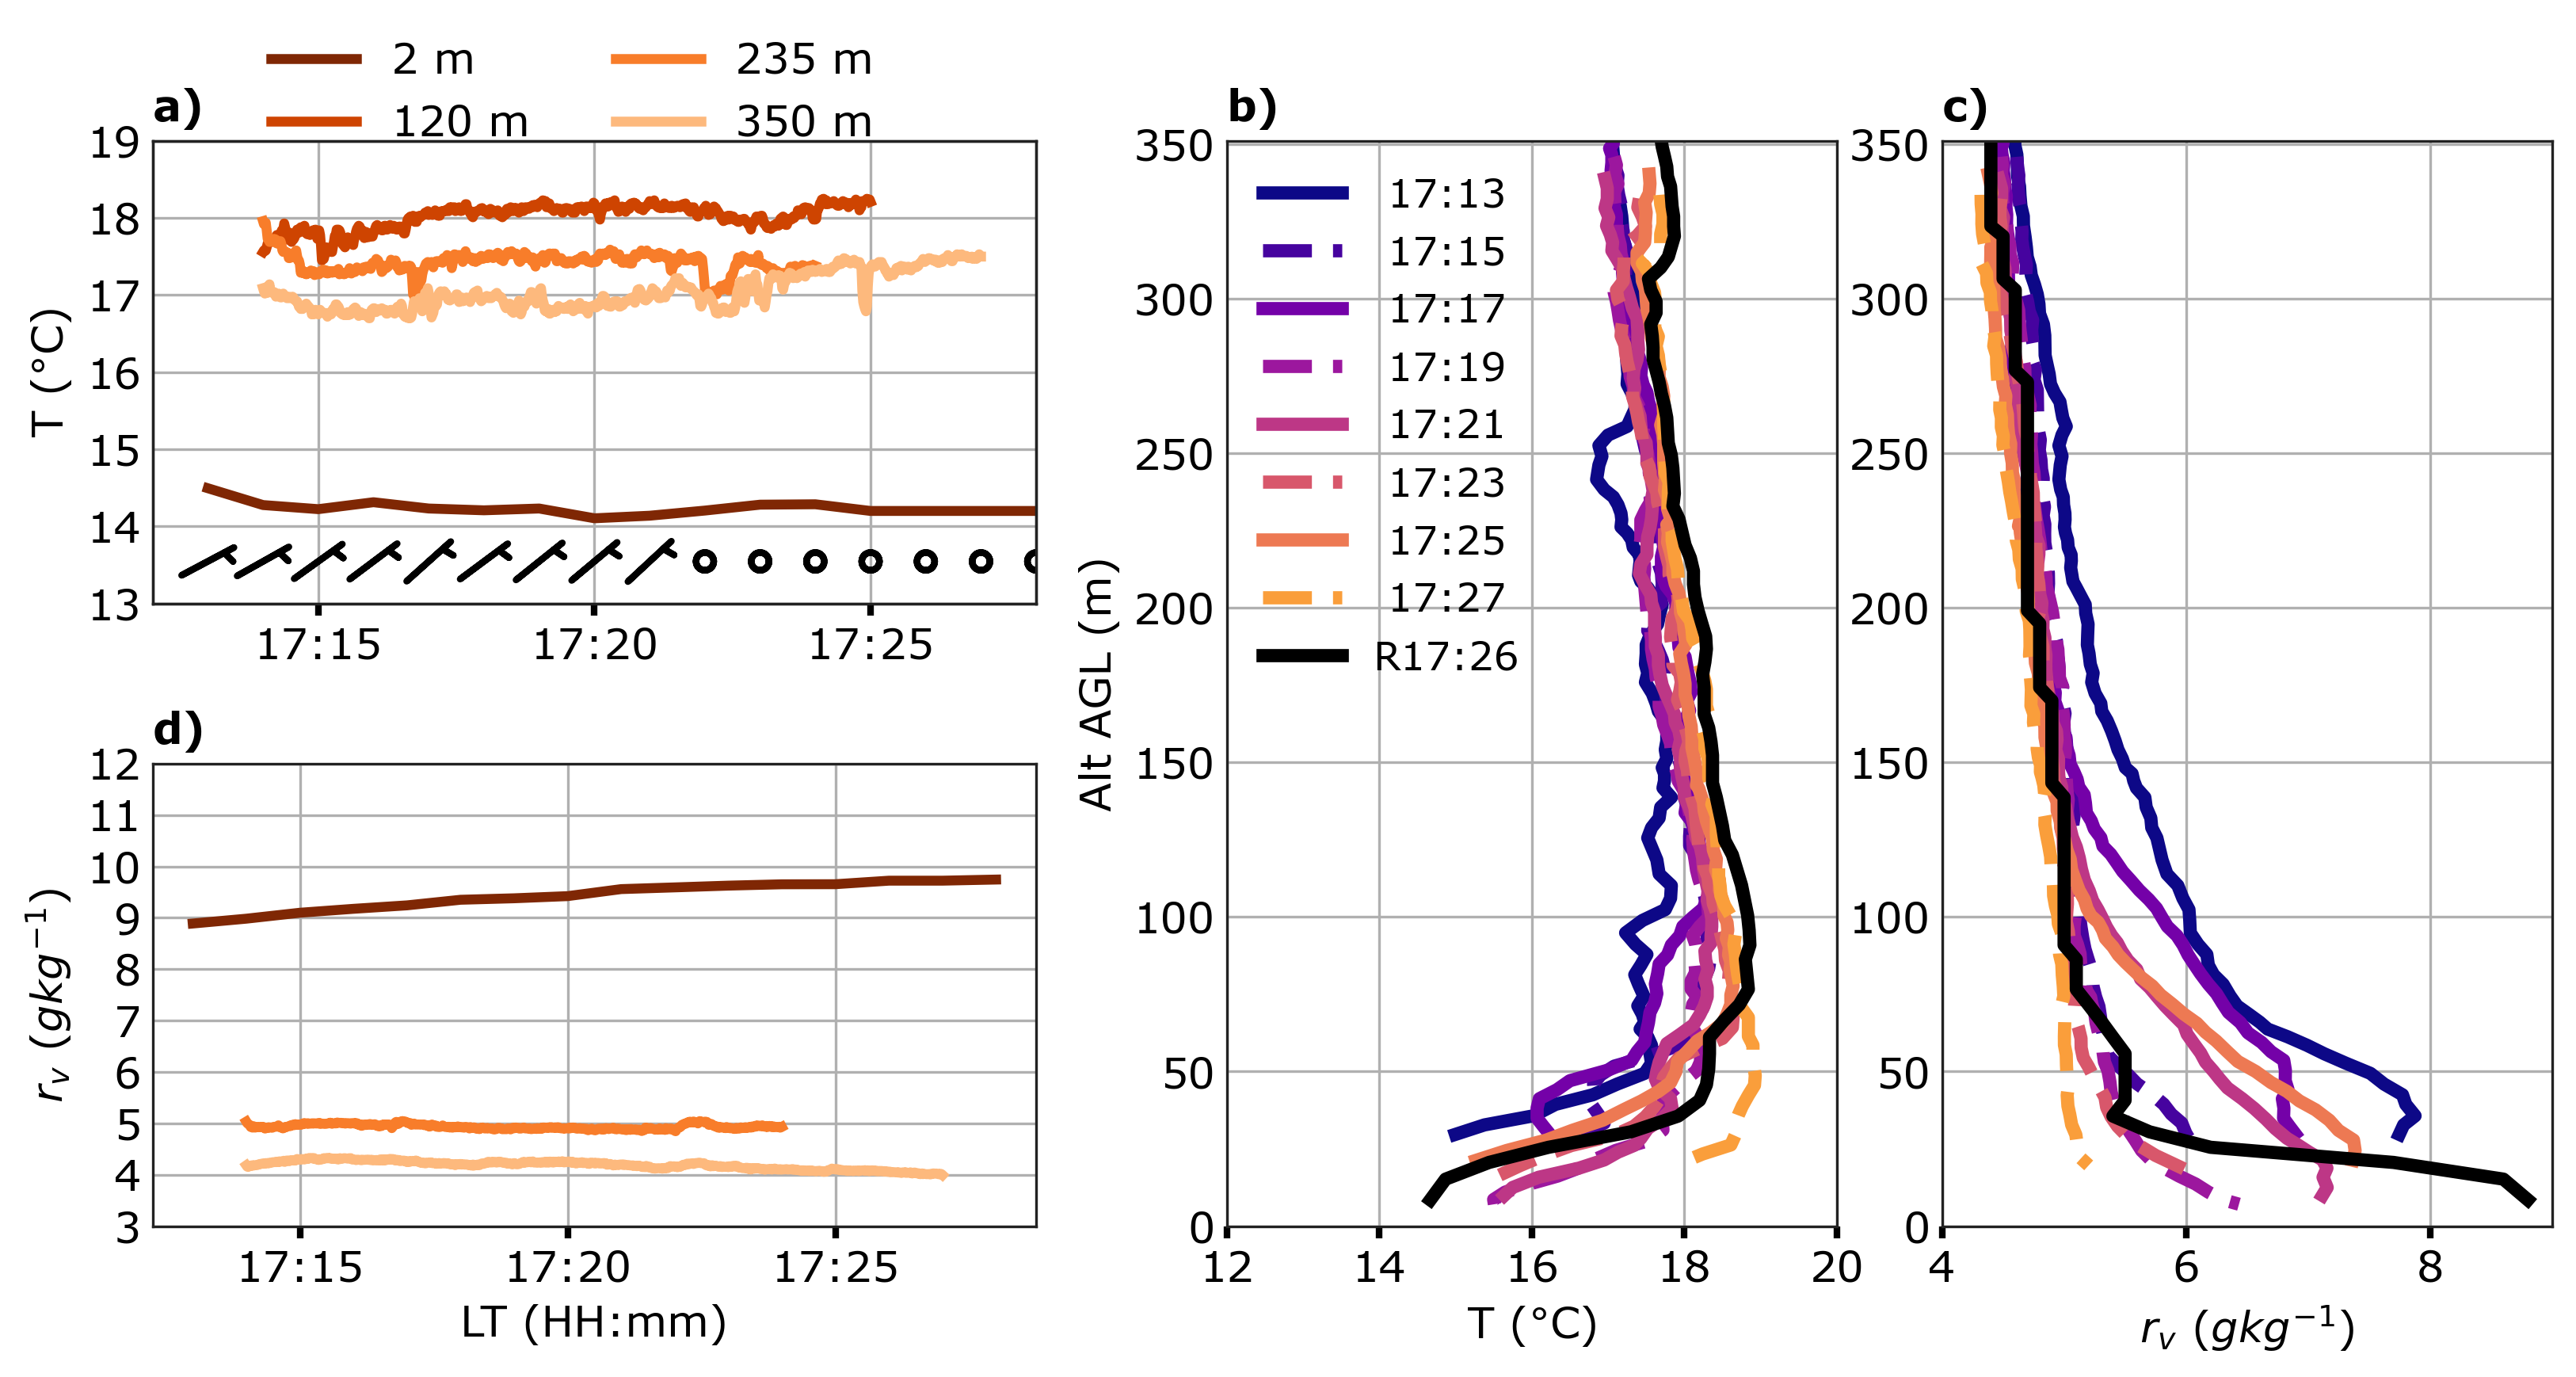

In [40]:
# fig, axes = plt.subplots(4,1)
fig = plt.figure(figsize=(11, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[2, 3])  # 4 rows, 2 columns

# 4 stacked vertical panels (left column)
ax1 = fig.add_subplot(gs[0, 0])
ax_2 = fig.add_subplot(gs[1, 0])

gs_right = gs[:, 1].subgridspec(1, 2)   # <-- horizontal split

ax5 = fig.add_subplot(gs_right[0, 0])
ax6 = fig.add_subplot(gs_right[0, 1])
num_levels = 10
cmap = plt.get_cmap('Oranges_r', num_levels)
cmap2 = plt.get_cmap('Blues_r', num_levels)
## IOP 23

ax = ax1

startdate = datetime(2023,6,10,23,12)
enddate = datetime(2023,6,10,23,28)
iop23_plot = iop23[(iop23.index > startdate) & (iop23.index <= enddate)]
ax.plot(iop23_plot["LT_Time"],iop23_plot.temperature, color = cmap(0), label = "2 m", linewidth = 3)
ymin, ymax = ax.get_ylim()

# ax.vlines(datetime(2023,6,10,21,23), ymax,ymin, 'r')

# ax2 = ax.twinx()
ax2 = ax_2
# ax2.plot(iop23_plot.index, iop23_plot.MR, color = blue)
ax2.plot(iop23_plot["LT_Time"], iop23_plot.MR, color = cmap(0), label = "_nolabel_", linewidth = 3)

ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))

ax3 = ax.twinx()

# Set the y-axis limits of the second axes to be below the first axes
ax3.set_ylim(-2, 20)

# Plot the wind barbs on the second axes
# ax3.barbs(iop23_plot.index[::1], np.zeros_like(iop23_plot.index[::1]), iop23_plot.u[::1], iop23_plot.v[::1], 
#           length=8, pivot='middle', color='black', linewidth = 2)
ax3.barbs(iop23_plot["LT_Time"][::1], np.zeros_like(iop23_plot["LT_Time"][::1]), iop23_plot.u[::1], iop23_plot.v[::1], 
          length=6, pivot='middle', color='black', linewidth = 2)
# Hide the y-axis of the second axes
ax3.yaxis.set_visible(False)
ax2.set_ylabel(r"$r_v$ ($g kg^{-1}$)", weight = "normal", fontsize = 13)#, color = blue)
ax.set_ylabel(r"T ($\degree$C)", weight = "normal",fontsize = 13)#, color = red)
startdate = datetime(2023,6,10,23-6,12)
enddate = datetime(2023,6,10,23-6,28)

title_list = ["a)", "d)", "e)"]
for index, alt in enumerate(alts[:]):
    # ax = axes[index]
    ax = ax1
    ax2 = ax_2
    ax.set_xlim(startdate, enddate)
    temp_stack = df_stack_flt_23[df_stack_flt_23["nominal_altitude"] == alt]
    ax.plot(temp_stack["LT_Time"], temp_stack.Temp.rolling(1).mean(), label = str(alt)+" m", color = cmap(index*.2+.2), linewidth = 3)
    # ax3 = ax.twinx()
    if not alt == 120: ### bad RH values for this sensor for IOP 23
        ax2.plot(temp_stack["LT_Time"], temp_stack["Mixing_ratio(g/kg)"], color = cmap(index*.2+.2), linewidth = 3, label = alt
                )

    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))



ax.set_ylim(13,19)
ax2.set_ylim(3,12)
ax.set_yticks(np.arange(13,20,1))
ax2.set_yticks(np.arange(3,13,1))
ax.grid()
ax2.grid()
ax.legend(bbox_to_anchor=(0.86, 1.3),ncols = 2, fontsize = 13)
ax.set_title("a)", fontsize = 13)
ax2.set_title("d)", fontsize = 13)
ax2.set_xlabel("LT (HH:mm)", fontsize = 13, weight = "normal")


for index,leg in enumerate(df_prof_flt_23.leg_id.unique()):
    temp_df = df_prof_flt_23[df_prof_flt_23["leg_id"]==leg]
    # if temp_df["ascent_flag"].iloc[0] == True:
    #     color = prof_colors_asc[index]
    # else:
    #     color = prof_colors_dsc[index]
    ax = ax5
    ax2 = ax6
    ax.plot(temp_df.Temp, temp_df.Alt-1665, 
             linestyle = "--" if temp_df["ascent_flag"].iloc[0] == False else "-",label = str(temp_df["LT"].iloc[0])[6:-3],
             linewidth = 4,
             color = plasma[index]
            )
    ax2.plot(temp_df["Mixing_ratio(g/kg)"], temp_df.Alt-1665,
             linestyle = "--" if temp_df["ascent_flag"].iloc[0] == False else "-",label = str(temp_df["LT"].iloc[0])[6:-3],
             linewidth = 4,
             color = plasma[index]
             )
ax.plot(radiosonde_23.Temp[1:]-273.15,radiosonde_23.Alt_AGL[1:], label = f"R{radiosonde_23["LT_Time"].dt.time.iloc[3].strftime("%H:%M")}", color = "k", linewidth = 4)
ax2.plot(radiosonde_23.Mix_Rat[1:],radiosonde_23.Alt_AGL[1:], label = '_nolabel_' , color = "k", linewidth = 4)
ax2.set_xlabel(r"$r_v$ ($g kg^{-1}$)", fontsize = 13, weight = "normal")
ax.set_title("b)", fontsize = 13)
ax2.set_title("c)", fontsize = 13)
#f"Sonde {radiosonde_23["LT_Time"].dt.time.iloc[3:-3]}"
ax.set_xlabel(r"T ($\degree$C)", fontsize = 13, weight = "normal")
ax.legend(fontsize = 12)
ax.set_ylabel("Alt AGL (m)", fontsize = 13, weight = "normal")
ax.set_xlim(12,20)
ax2.set_xlim(4,9)
ax.set_ylim(0,351)
ax2.set_ylim(0,351)
ax2.grid()
ax.grid()
plt.tight_layout()
plt.savefig(figPath+"Fig2_ad", dpi = 600)
plt.show()
plt.close()

## Code for plotting figure 2e-h

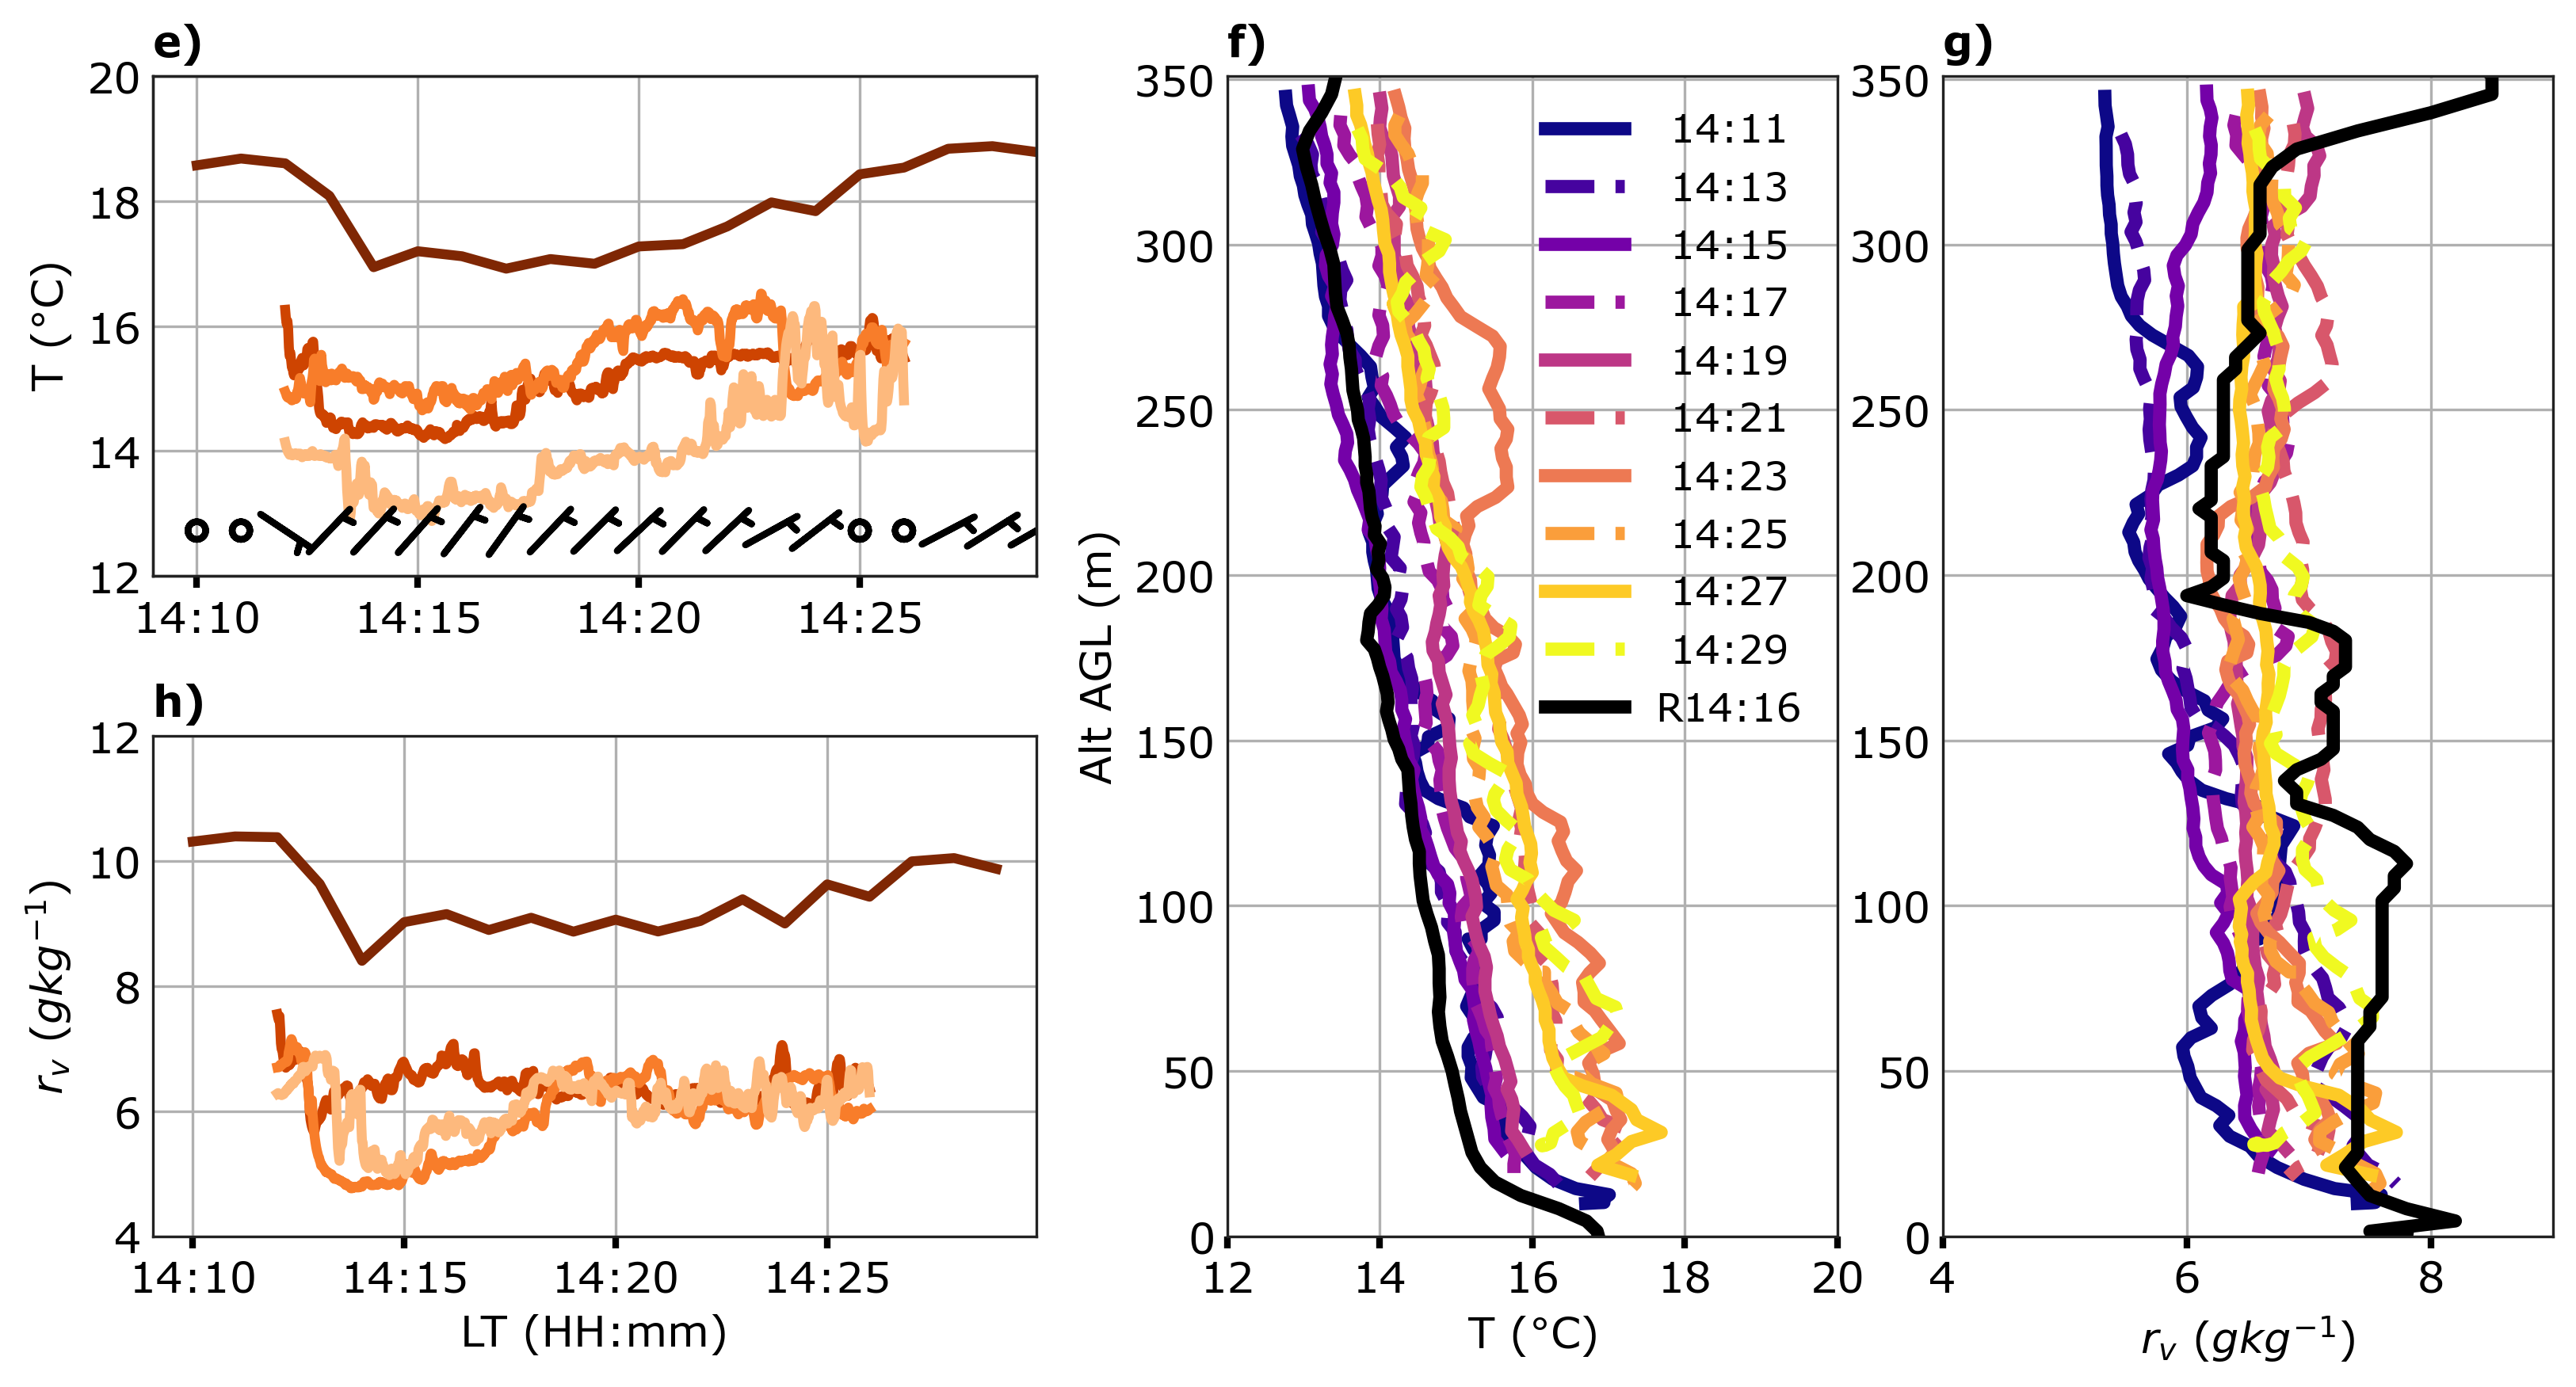

In [41]:
fig = plt.figure(figsize=(11, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[2, 3])  # 4 rows, 2 columns

# 4 stacked vertical panels (left column)
ax1 = fig.add_subplot(gs[0, 0])
ax_2 = fig.add_subplot(gs[1, 0])

# Right column: split into 1 row, 2 columns
gs_right = gs[:, 1].subgridspec(1, 2)   # <-- horizontal split

ax5 = fig.add_subplot(gs_right[0, 0])
ax6 = fig.add_subplot(gs_right[0, 1])

## IOP 26

ax = ax1

startdate = datetime(2023,6,17,20,9)
enddate = datetime(2023,6,17,20,29)
iop26_plot = iop26[(iop26.index > startdate) & (iop26.index <= enddate)]
ax.plot(iop26_plot["LT_Time"], iop26_plot.temperature, color = cmap(0), label = "2 m", linewidth = 3)
ymin, ymax = ax.get_ylim()


ax2 = ax_2
ax2.plot(iop26_plot["LT_Time"], iop26_plot.MR, color = cmap(0), linewidth = 3)

ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))

ax3 = ax.twinx()

# Set the y-axis limits of the second axes to be below the first axes
ax3.set_ylim(-2, 20)

ax3.barbs(iop26_plot["LT_Time"][::1], np.zeros_like(iop26_plot["LT_Time"][::1]), iop26_plot.u[::1], iop26_plot.v[::1], 
          length=6, pivot='middle', color='black', linewidth = 2)
startdate = datetime(2023,6,17,20-6,9)
enddate = datetime(2023,6,17,20-6,29)

for index, alt in enumerate(alts[:]):
    # ax = axes[index]
    ax = ax1
    ax.set_xlim(startdate, enddate)
    temp_stack = df_stack_flt_26[df_stack_flt_26["nominal_altitude"] == alt]
    ax.plot(temp_stack["LT_Time"], temp_stack.Temp.rolling(1).mean(), label = str(alt) + " m", color = cmap(index*.2+.2), linewidth = 3)
    ax2 = ax_2
    # if not alt == 120: ### bad RH values for this sensor for IOP 23
    ax2.plot(temp_stack["LT_Time"], temp_stack["Mixing_ratio(g/kg)"], color = cmap(index*.2+.2), linewidth = 3, label = "_nolabel"
                )

    
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))


# Hide the y-axis of the second axes
ax3.yaxis.set_visible(False)
# ax.legend(bbox_to_anchor=(0.85, 1.3),ncols = 2, fontsize = 12)
ax.set_title("e)", fontsize = 13)
ax2.set_title("h)", fontsize = 13)
ax2.set_ylabel(r"$r_v$ ($g kg^{-1}$)", fontsize = 13, weight = "normal")
ax.set_ylabel(r"T ($\degree$C)", fontsize = 13, weight = "normal")
# ax.set_ylim(13.5,15.5)
# ax2.set_ylim(7.5,10.5)
ax.set_ylim(12,20)
ax2.set_ylim(4,12)
ax.set_yticks(np.arange(12,21,2))
ax2.set_yticks(np.arange(4,13,2))
ax.grid()
ax2.grid()
ax2.set_xlabel("LT (HH:mm)", fontsize = 13, weight = "normal")

for index,leg in enumerate(df_prof_flt_26.leg_id.unique()):
    temp_df = df_prof_flt_26[df_prof_flt_26["leg_id"]==leg]

    ax = ax5
    ax2 = ax6
    ax.plot(temp_df.Temp, temp_df.Alt-1645, 
             linestyle = "--" if temp_df["ascent_flag"].iloc[0] == False else "-",label = str(temp_df["LT"].iloc[0])[6:-3],
             linewidth = 4,
             color = plasma[index]
            )
    ax2.plot(temp_df["Mixing_ratio(g/kg)"], temp_df.Alt-1645,
             linestyle = "--" if temp_df["ascent_flag"].iloc[0] == False else "-",label = str(temp_df["LT"].iloc[0])[6:-3],
             linewidth = 4,
             color = plasma[index]
             )
ax.plot(radiosonde_26.Temp[1:]-273.15,radiosonde_26.Alt_AGL[1:], label = f"R{radiosonde_26["LT_Time"].dt.time.iloc[3].strftime("%H:%M")}", color = "k", linewidth = 4)

ax2.plot(radiosonde_26.Mix_Rat[1:],radiosonde_26.Alt_AGL[1:], label = f"Sonde {radiosonde_26["LT_Time"].dt.time.iloc[3].strftime("%H:%M")}", color = "k", linewidth = 4)

ax2.set_xlabel(r"$r_v$ ($g kg^{-1}$)", fontsize = 13, weight = "normal")
ax.set_xlabel(r"T ($\degree$C)", fontsize = 13, weight = "normal")
ax.set_title("f)", fontsize = 13)
ax2.set_title("g)", fontsize = 13)
ax.legend(fontsize = 12)
plt.ylabel("Alt AGL (m)", fontsize = 13, weight = "normal")
ax.set_xlim(12,20)
ax2.set_xlim(4,9)
ax.set_ylim(0,351)
ax2.set_ylim(0,351)
ax.set_ylabel("Alt AGL (m)", fontsize = 13, weight = "normal")
ax2.grid()
ax.grid()
plt.tight_layout()
plt.savefig(figPath+"Fig2_eg", dpi = 600)
plt.show()
plt.close()